<a href="https://colab.research.google.com/github/ahalyamukundan24/Case_Study_on_ML_Application_Deployment/blob/main/ML_Application_Deployment_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/beer-servings.csv")
df.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 10.7+ KB


In [6]:
df.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
country,0
beer_servings,8
spirit_servings,8
wine_servings,6
total_litres_of_pure_alcohol,1
continent,0


## Infographic Graphs
### Beer vs Alcohol

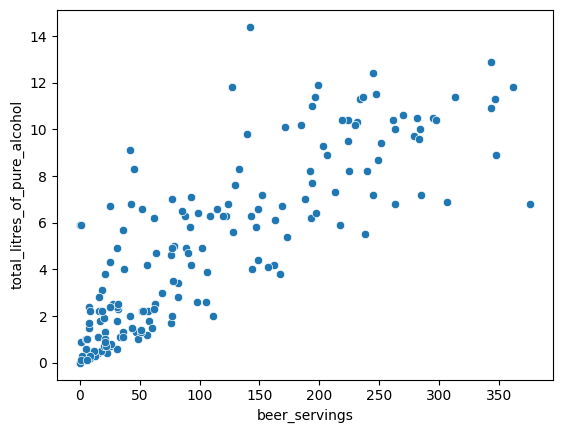

In [8]:
sns.scatterplot(x="beer_servings",y="total_litres_of_pure_alcohol",data=df)
plt.show()

### Wine vs Alcohol

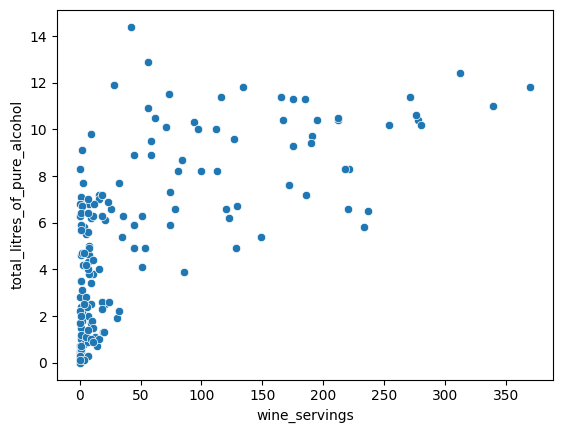

In [9]:
sns.scatterplot(x="wine_servings",y="total_litres_of_pure_alcohol",data=df)
plt.show()

### Spirit vs Alcohol

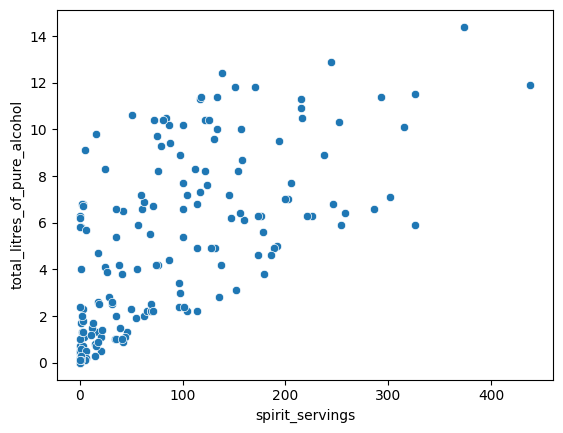

In [10]:
sns.scatterplot(x="spirit_servings",y="total_litres_of_pure_alcohol",data=df)
plt.show()

### Continent distribution

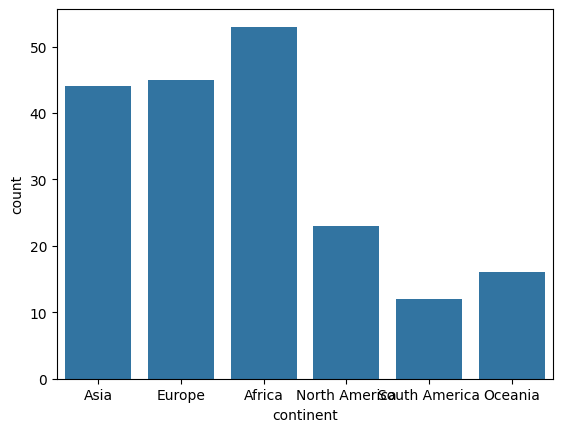

In [11]:
sns.countplot(x="continent",data=df)
plt.show()

In [12]:
df = df.drop("country",axis=1)

In [13]:
df = pd.get_dummies(df,columns=["continent"],drop_first=True)

In [14]:
X = df.drop("total_litres_of_pure_alcohol", axis=1)
y = df["total_litres_of_pure_alcohol"]

In [15]:
X = X.fillna(0)
y = y.fillna(0)

## Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [18]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression R2 Score:", r2_lr)

Linear Regression R2 Score: 0.9052812350927805


## Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [20]:
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest R2 Score:", r2_rf)

Random Forest R2 Score: 0.8184994002234844


In [21]:
print("Linear Regression:", r2_lr)
print("Random Forest:", r2_rf)

Linear Regression: 0.9052812350927805
Random Forest: 0.8184994002234844


## Hyperparameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

model = LinearRegression()

param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid = GridSearchCV(model, param_grid, cv=5)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'fit_intercept': True, 'positive': False}


In [23]:
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

from sklearn.metrics import r2_score

r2_best = r2_score(y_test, pred_best)

print("Tuned Model R2 Score:", r2_best)

Tuned Model R2 Score: 0.9052812350927805


In [24]:
import pickle

pickle.dump(best_model, open("alcohol_model.pkl", "wb"))